In [ ]:
import pandas as pd

df = pd.read_csv("postings.csv", engine="python", on_bad_lines="skip")

df.head()


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [ ]:
df.shape


(1814, 31)

In [ ]:
df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1814 entries, 0 to 1813
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      1814 non-null   int64  
 1   company_name                1709 non-null   object 
 2   title                       1814 non-null   object 
 3   description                 1814 non-null   object 
 4   max_salary                  575 non-null    float64
 5   pay_period                  654 non-null    object 
 6   location                    1814 non-null   object 
 7   company_id                  1710 non-null   float64
 8   views                       1798 non-null   float64
 9   med_salary                  79 non-null     float64
 10  min_salary                  575 non-null    float64
 11  formatted_work_type         1814 non-null   object 
 12  applies                     687 non-null    float64
 13  original_listed_time        1814 

In [ ]:
df.isnull().sum()

,0
job_id,0
company_name,105
title,0
description,0
max_salary,1239
pay_period,1160
location,0
company_id,104
views,16
med_salary,1735


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=[
    'job_posting_url',
    'application_url',
    'zip_code',
    'fips',
    'closed_time'
], errors='ignore')

In [ ]:
df = df.drop(columns=[
    'job_posting_url',
    'application_url',
    'closed_time',
    'skills_desc',
    'posting_domain',
    'zip_code',
    'fips'
], errors='ignore')

In [ ]:
df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'application_type', 'expiry',
       'formatted_experience_level', 'listed_time', 'sponsored', 'work_type',
       'currency', 'compensation_type', 'normalized_salary'],
      dtype='object')

In [ ]:
df.to_csv("cleaned_postings.csv", index=False)

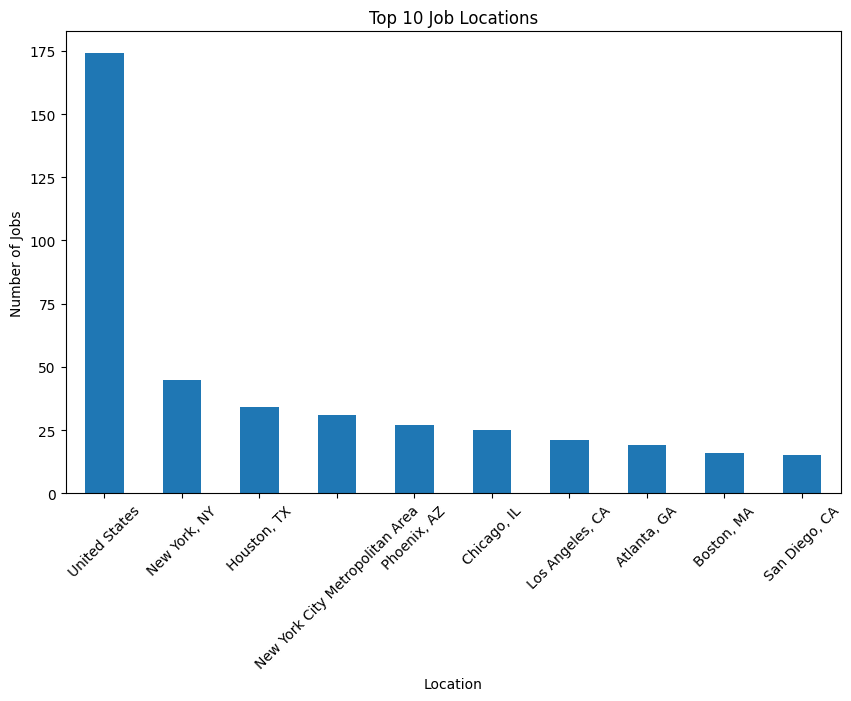

In [ ]:
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_locations.plot(kind='bar')
plt.title("Top 10 Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

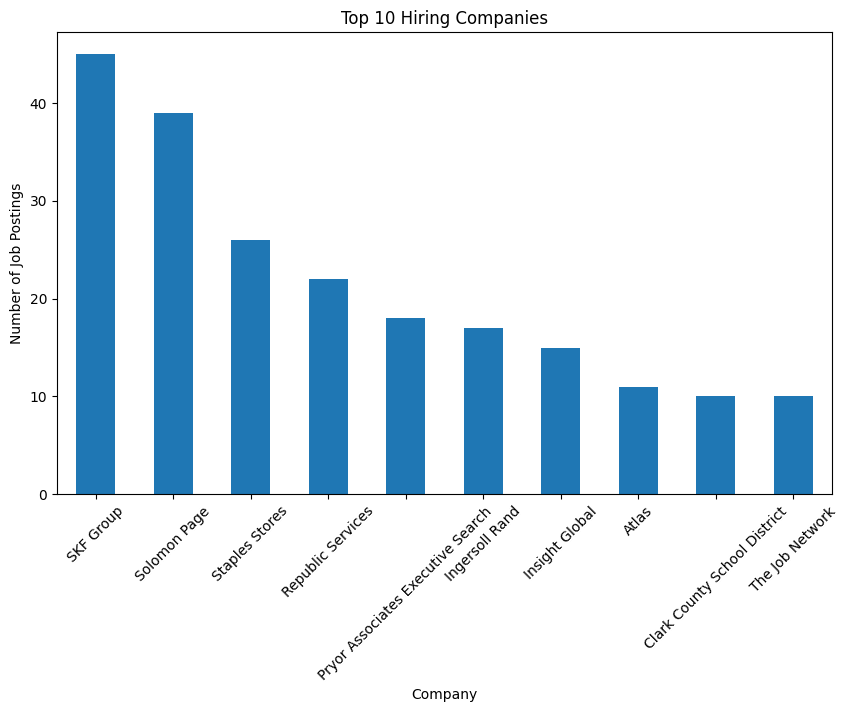

In [ ]:
top_companies = df['company_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_companies.plot(kind='bar')

plt.title("Top 10 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

plt.show()

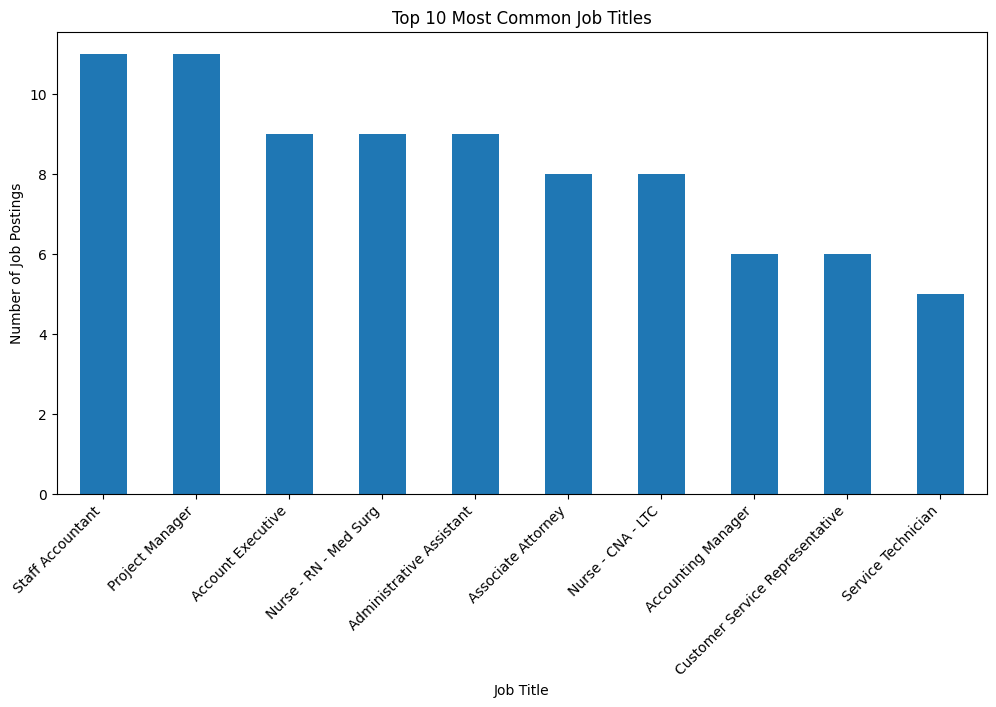

In [ ]:
import matplotlib.pyplot as plt

top_titles = df['title'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_titles.plot(kind='bar')

plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha='right')

plt.show()

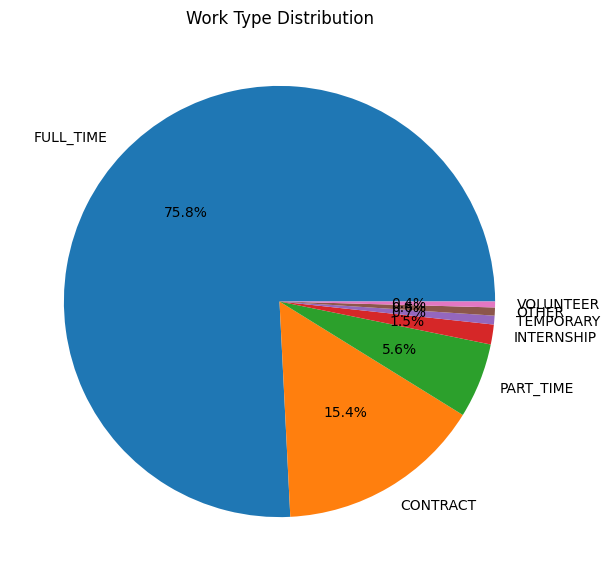

In [ ]:
work_type = df['work_type'].value_counts()

plt.figure(figsize=(7,7))
work_type.plot(kind='pie', autopct='%1.1f%%')

plt.title("Work Type Distribution")
plt.ylabel("")
plt.show()

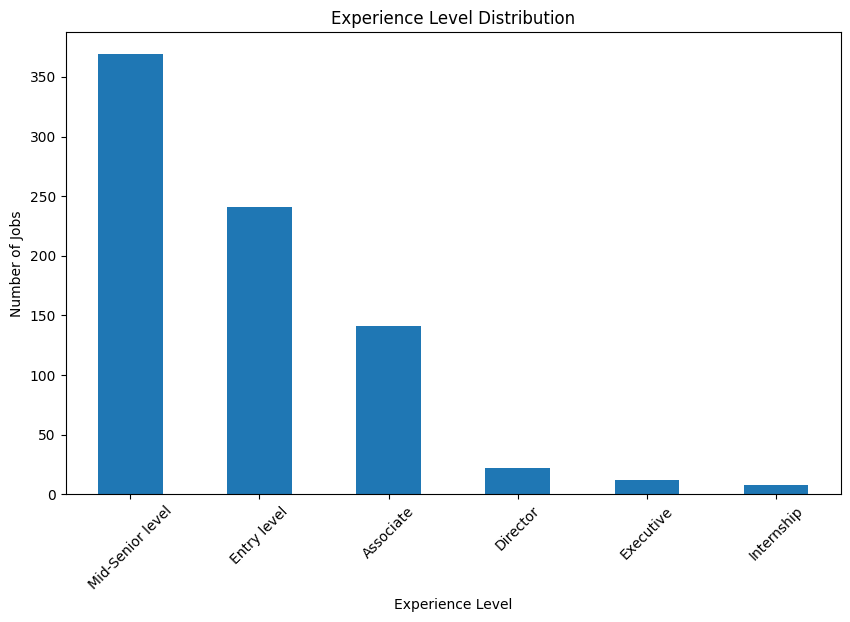

In [ ]:
experience = df['formatted_experience_level'].value_counts().head(10)

plt.figure(figsize=(10,6))
experience.plot(kind='bar')

plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

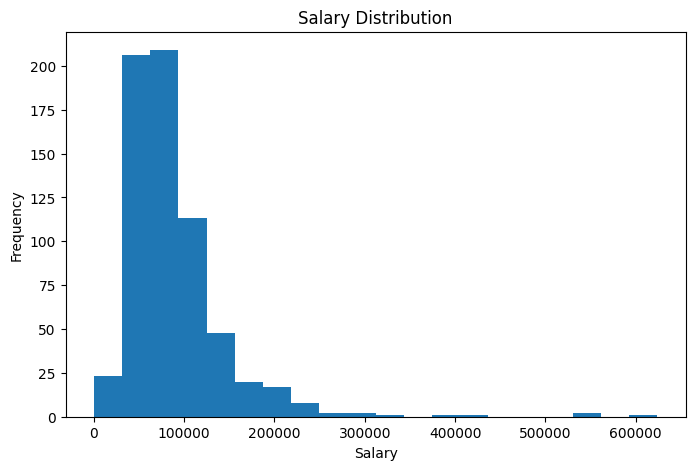

In [ ]:
salary = df['normalized_salary'].dropna()

plt.figure(figsize=(8,5))
plt.hist(salary, bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

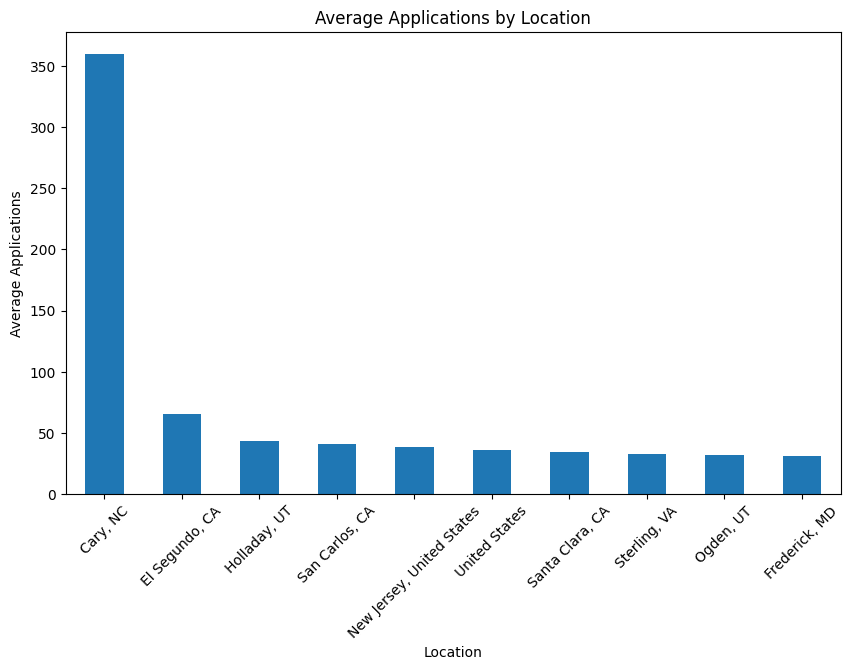

In [ ]:
top_apply = df.groupby('location')['applies'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_apply.plot(kind='bar')

plt.title("Average Applications by Location")
plt.xlabel("Location")
plt.ylabel("Average Applications")

plt.xticks(rotation=45)

plt.show()

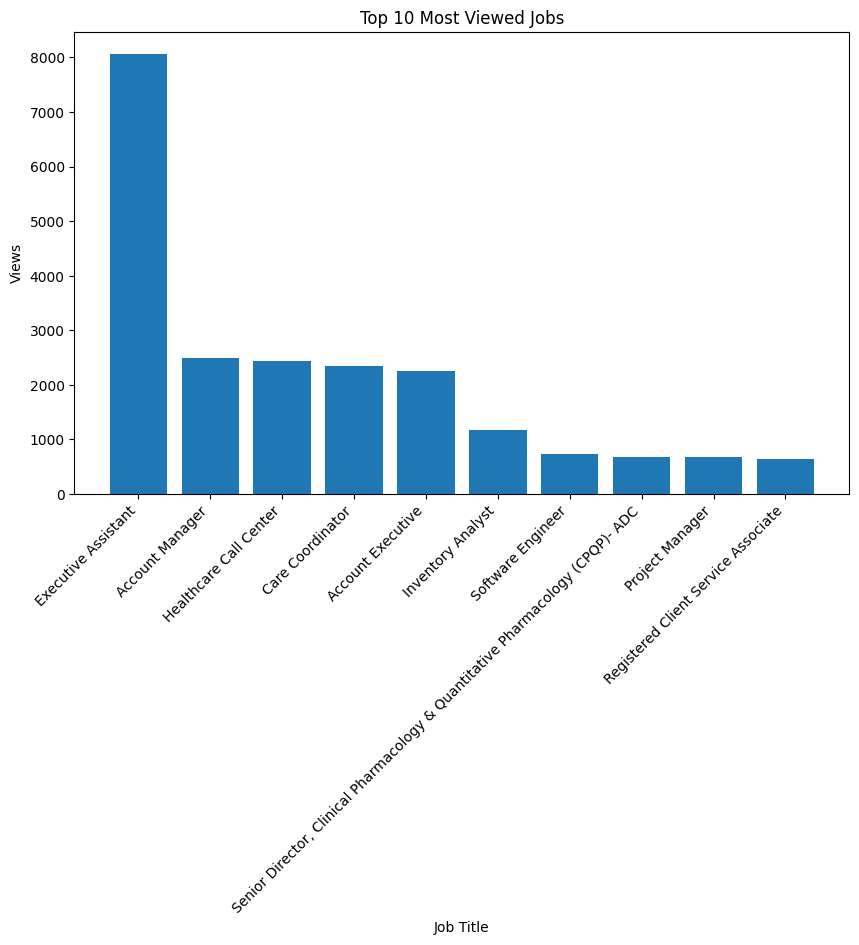

In [ ]:
top_views = df.nlargest(10, 'views')[['title', 'views']]

plt.figure(figsize=(10,6))
plt.bar(top_views['title'], top_views['views'])

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Most Viewed Jobs")
plt.xlabel("Job Title")
plt.ylabel("Views")

plt.show()

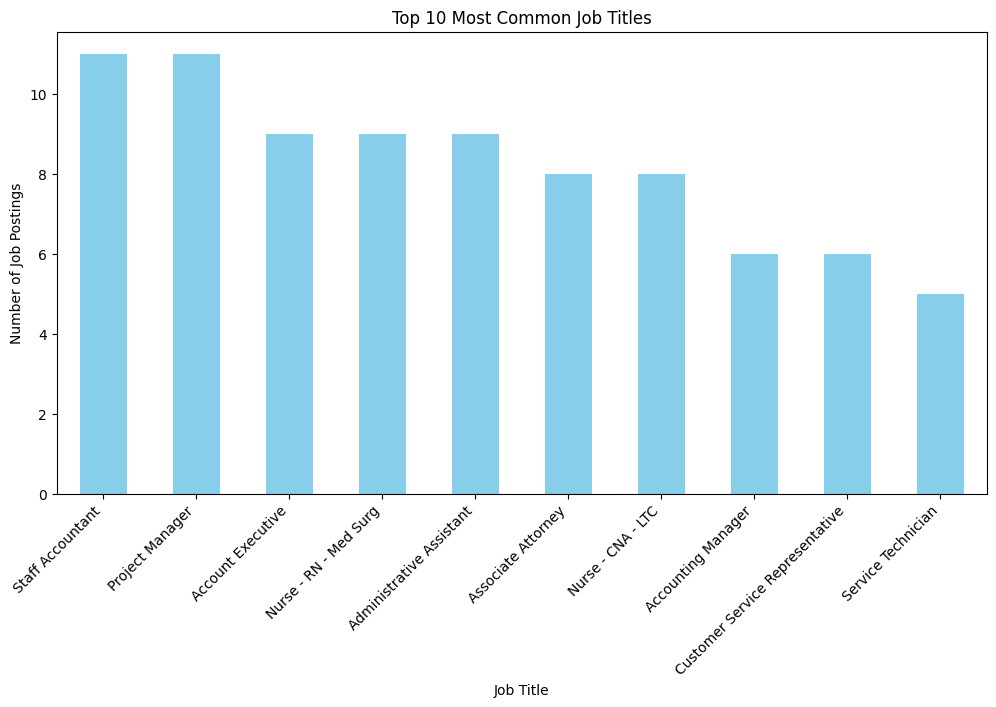

In [ ]:
import matplotlib.pyplot as plt

top_titles = df['title'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_titles.plot(kind='bar', color='skyblue')

plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha='right')

plt.show()

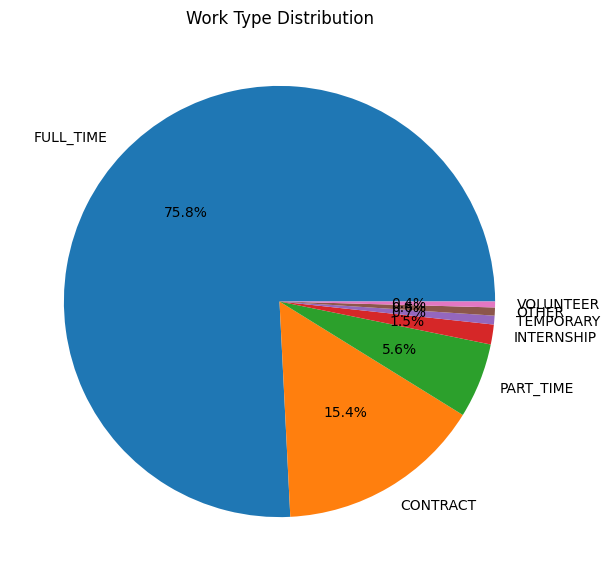

In [ ]:
work_type = df['work_type'].value_counts()

plt.figure(figsize=(7,7))
work_type.plot(kind='pie', autopct='%1.1f%%')

plt.title("Work Type Distribution")
plt.ylabel("")

plt.show()

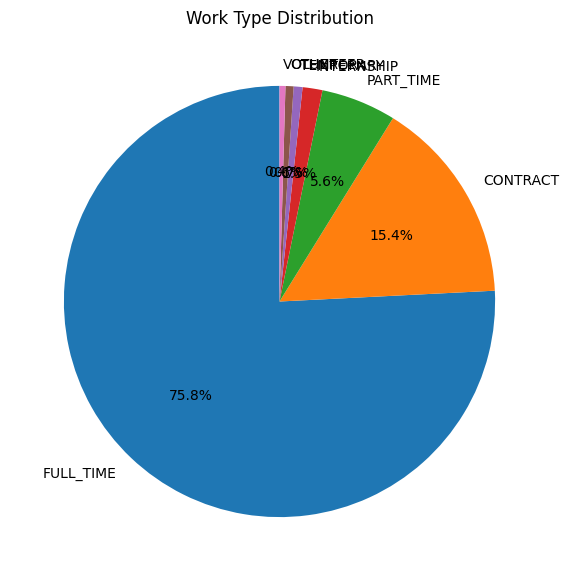

In [ ]:
import matplotlib.pyplot as plt

work_type = df['work_type'].value_counts()

plt.figure(figsize=(7,7))
work_type.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title("Work Type Distribution")
plt.ylabel("")

plt.show()

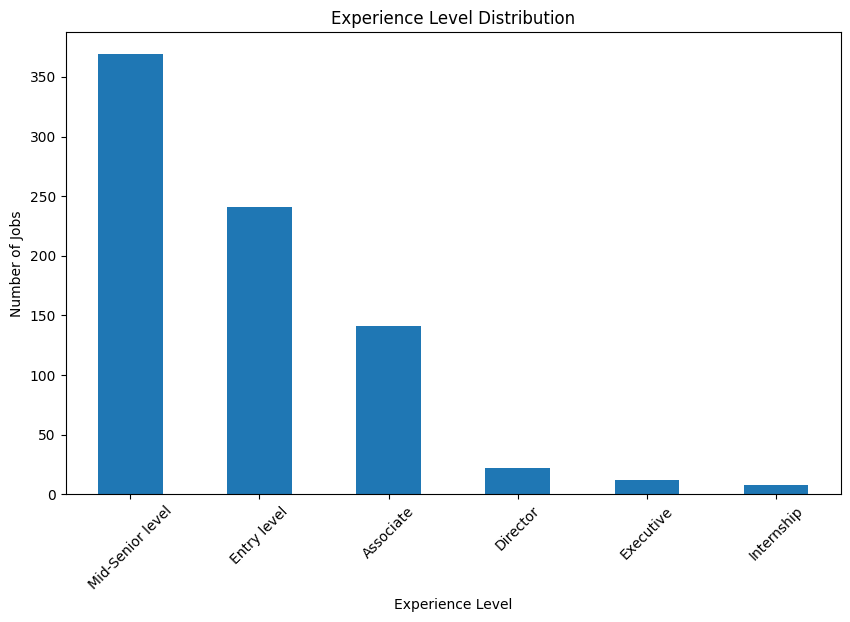

In [ ]:
experience = df['formatted_experience_level'].value_counts()

plt.figure(figsize=(10,6))
experience.plot(kind='bar')

plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

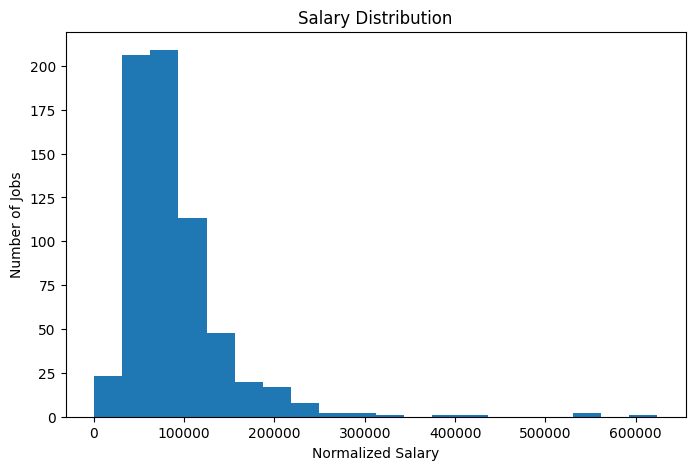

In [ ]:
salary = df['normalized_salary'].dropna()

plt.figure(figsize=(8,5))
plt.hist(salary, bins=20)

plt.title("Salary Distribution")
plt.xlabel("Normalized Salary")
plt.ylabel("Number of Jobs")

plt.show()

In [ ]:
skills = [
    "Python", "SQL", "Excel", "Power BI", "Tableau",
    "Machine Learning", "Java", "AWS", "Azure",
    "C++", "R", "TensorFlow", "Spark"
]

skill_count = {}

for skill in skills:
    skill_count[skill] = df['description'].str.contains(skill, case=False, na=False).sum()

skill_count

{'Python': np.int64(69),
 'SQL': np.int64(104),
 'Excel': np.int64(962),
 'Power BI': np.int64(22),
 'Tableau': np.int64(14),
 'Machine Learning': np.int64(10),
 'Java': np.int64(65),
 'AWS': np.int64(246),
 'Azure': np.int64(53),
 'C++': np.int64(1813),
 'R': np.int64(1813),
 'TensorFlow': np.int64(1),
 'Spark': np.int64(13)}

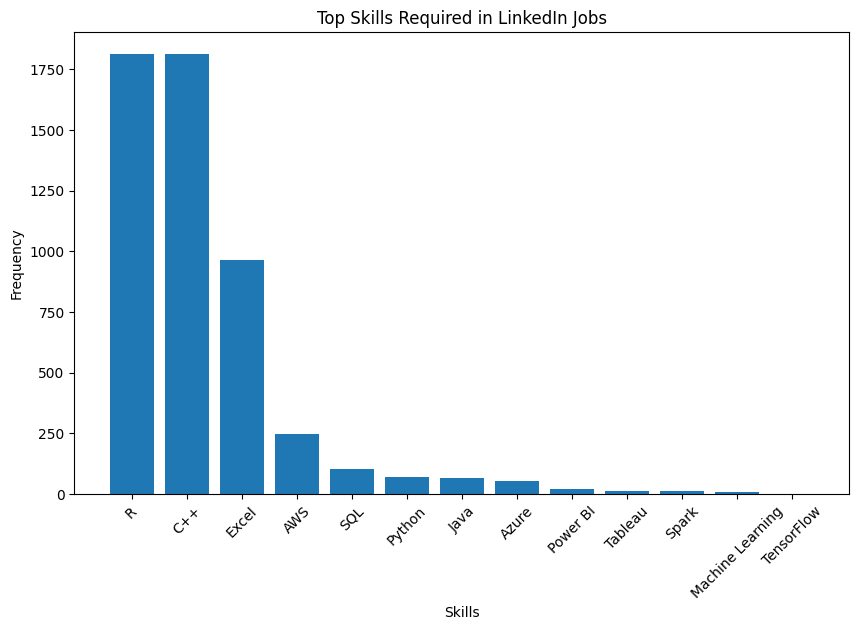

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

skill_df = pd.DataFrame(skill_count.items(), columns=['Skill', 'Count'])

skill_df = skill_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(skill_df['Skill'], skill_df['Count'])

plt.title("Top Skills Required in LinkedIn Jobs")
plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df.to_csv("cleaned_postings.csv", index=False)

In [ ]:
skills = [
    "Python", "SQL", "Excel", "Power BI", "Tableau",
    "Machine Learning", "Java", "AWS", "Azure",
    "TensorFlow", "Spark", "C++", "R"
]

for skill in skills:
    df[skill] = df['description'].str.contains(skill, case=False, na=False)

In [ ]:
skill_matrix = df.groupby('title')[skills].sum()

skill_matrix.head()

,Python,SQL,Excel,Power BI,Tableau,Machine Learning,Java,AWS,Azure,TensorFlow,Spark,C++,R
title,,,,,,,,,,,,,
GCP Data Engineer (Only W2),0,1,0,0,0,0,0,0,0,0,0,1,1
Information Technology Epic Beaker Application Analyst 2,0,0,0,0,0,0,0,0,0,0,0,1,1
Junior ETL QA Test Engineer,1,1,1,0,0,0,0,1,1,0,1,1,1
SAP PP MM/QM,0,0,0,0,0,0,0,0,0,0,0,1,1
Service Technician,0,0,0,0,0,0,0,0,0,0,0,1,1


In [ ]:
skill_matrix.to_csv("Skill_vs_Role_Matrix.csv", index=True)

In [ ]:
df.to_csv("LinkedIn_Cleaned_Data.csv", index=False)

In [ ]:
skill_matrix.to_csv("Skill_vs_Role_Matrix.csv")